<a href="https://colab.research.google.com/github/iris-hep/nsbi-lhc-toolkit/blob/ml4hep_school_tutorial/workshops/ml4hep_tifr_colab/Exercise_2_2b_BkgvsRef_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
## ============================================================================
# Google Colab setup — run me first.  Safe to re-run; a no-op off Colab.
# ============================================================================
import os, sys

# --- config -----------------------------------------------------------------
REPO_URL = "https://github.com/iris-hep/nsbi-lhc-toolkit.git"  # package + tutorial helpers
BRANCH   = "ml4hep_school_tutorial"
N_BKG, N_SIG = 5_000_000, 5_000_000     # Colab-sized dataset (raise for less MC noise in the fit)
USE_DRIVE = True                    # True -> save data/models to Google Drive so they
                                    # persist across notebooks & sessions (see notes above)
# ----------------------------------------------------------------------------

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if USE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")
        ROOT = "/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab"
    else:
        ROOT = "/content"
    os.makedirs(ROOT, exist_ok=True)
    os.chdir(ROOT)

    # 1) fetch ONLY the package source + tutorial helpers (skip Git-LFS / big blobs)
    if not os.path.isdir("nsbi-lhc-toolkit"):
        os.environ["GIT_LFS_SKIP_SMUDGE"] = "1"
        !git clone --depth 1 --filter=blob:none --sparse --branch $BRANCH $REPO_URL
        !cd nsbi-lhc-toolkit && git sparse-checkout set src workshops/ml4hep_tifr_colab

    # 2) make `import nsbi_common_utils` work (pure-python src layout, no build step)
    src = os.path.abspath("nsbi-lhc-toolkit/src")
    if src not in sys.path:
        sys.path.insert(0, src)

    # 3) runtime deps Colab doesn't already ship (torch/jax/sklearn/... are preinstalled)
    !pip install -q pytorch-lightning onnx onnxruntime onnxscript iminuit mplhep

    # 4) work from the tutorial dir so utils.py / generate_distributions.py and the
    #    ./dataframes, ./models_* relative paths resolve just like a local run
    os.chdir("nsbi-lhc-toolkit/workshops/ml4hep_tifr_colab")

    # 5) generate the Gaussian-mixture samples if they aren't there yet
    if not os.path.exists("dataframes/signal.parquet"):
        !python generate_distributions.py --n_bkg $N_BKG --n_sig $N_SIG

print("Working dir:", os.getcwd())

Working dir: /Users/jaysandesara/Documents/NSBI-workflow-tutorial/workshops/ml4hep_tifr_colab


Density Ratio Training - Background vs Reference
---

In the 2a and 2b notebooks we set up the neural networks that train unbiased, low-variance **density ratios**, used to build the SBI model

$$ \frac{L(\mu)}{\prod_e p_\mathrm{ref}(x_e)} = \prod_{x_e\in \{x\}} \frac{1}{\mu \cdot \lambda_\mathrm{sig} + \lambda_\mathrm{bkg}} \left[\mu \cdot \lambda_\mathrm{sig} \cdot \frac{p_\mathrm{sig}(x_e)}{p_\mathrm{ref}(x_e)} + \lambda_\mathrm{bkg} \cdot \frac{p_\mathrm{bkg}(x_e)}{p_\mathrm{ref}(x_e)}\right]$$

which we then use to build the test statistic in the `3_parameter_fitting.ipynb` notebook. The two ratios to estimate with neural networks are

$$ R_\psi^\mathrm{sig}(x) \approx \frac{p_\mathrm{sig}(x)}{p_\mathrm{ref}(x)}, \qquad  R_\psi^\mathrm{bkg}(x) \approx \frac{p_\mathrm{bkg}(x)}{p_\mathrm{ref}(x)}. $$

Following the lecture, each ratio is obtained **not by regressing the ratio directly**, but by training a classifier to separate the target sample ($y=1$) from the reference ($y=0$). The network outputs a score $q_\psi(y=1\mid x)$, optimised with the (weight-balanced) binary cross-entropy

$$ \mathcal{L}_\mathrm{BCE}[q_\psi] = -\,\mathbb{E}_{(x,y)\sim p(x,y)}\big[\,y\log q_\psi + (1-y)\log(1-q_\psi)\,\big], $$

and at the optimum the density ratio is recovered from the score as

$$ R_\psi(x) = \frac{q_\psi(y=1\mid x)}{1 - q_\psi(y=1\mid x)} \approx \frac{p(x)}{p_\mathrm{ref}(x)}. $$

In this notebook we use `nsbi-common-utils` to estimate $R_\psi^\mathrm{bkg}(x)$ (background vs. reference); notebook 2a does the same for $R_\psi^\mathrm{sig}(x)$ (signal vs. reference). Because the reference hypothesis contains the background itself, this ratio is bounded by construction (it cannot exceed the inverse of the background mixing fraction in the reference).

In [1]:
import nsbi_common_utils
import pandas as pd
import numpy as np
import mplhep as hep
import matplotlib.pyplot as plt

Insert the path to the downloaded dataset (see README for download link)

In [2]:
BASE_PATH = "./dataframes/"

Load the signal and background datasets

In [3]:
signal = pd.read_parquet(f"{BASE_PATH}/signal.parquet")
background = pd.read_parquet(f"{BASE_PATH}/background.parquet")

### Train / inference split

The density ratios must be **trained** and the likelihood **evaluated** on *different* events, otherwise the parameter fit inherits the classifier's overfitting. We split each sample with a fixed seed: the training notebooks (2a, 2b) keep the *training* half and the fitting notebook (3) keeps the *inference* half.

`SPLIT_SEED` and `TRAIN_FRACTION` **must be identical across all three notebooks** — the shared seed is what guarantees the two halves are disjoint. Change `TRAIN_FRACTION` (or pass `n_train=<int>` to `split_train_inference`) to adjust how many events go to training vs. inference.

In [4]:
from utils import split_train_inference

SPLIT_SEED = 0
TRAIN_FRACTION = 0.5  # fraction of each sample used for TRAINING

signal, _ = split_train_inference(signal, train_fraction=TRAIN_FRACTION, seed=SPLIT_SEED)
background, _ = split_train_inference(background, train_fraction=TRAIN_FRACTION, seed=SPLIT_SEED)

print(f"Training on {len(signal):,} signal + {len(background):,} background events")

Training on 2,500,000 signal + 2,500,000 background events


We will use the full high-dimensional feature space to train the density ratios

In [5]:
training_features = ["x1", "x2", "x3", "x4", "x5"]

The numerator and denominator hypothesis refer to the background and reference hypothesis respectively for this notebook. Remember, the objective is to train a classifier score $q_\psi(y=1\mid x)$ whose odds estimate

$$ R_\psi^\mathrm{bkg}(x) = \frac{q_\psi(y=1\mid x)}{1 - q_\psi(y=1\mid x)} \approx \frac{p_\mathrm{bkg}(x)}{p_\mathrm{ref}(x)} $$

We will choose the reference hypothesis to be a combination of the signal and background so there are no phase space regions with $p_\mathrm{ref}(x) \approx 0$ during training.

The choice of reference is one of the difficult and less well-defined parts of the SBI approach -  it has significant impact on numerical stability.

In [6]:
numerator_hypothesis = background.astype('float32').copy()
denominator_hypothesis = pd.concat([background, signal], ignore_index=True).astype('float32').copy()

Build a combined training dataset consisting of events from numerator and denominator hypothesis. By using `weights_normed` the binary cross-entropy loss function sees both classes represented equally, allowing us to use the likelihood-ratio trick for density ratio estimation. `train_labels` correspond to the truth labels that go into the binary cross-entropy loss function.

In [7]:
numerator_hypothesis["weights"] = numerator_hypothesis['weight']
numerator_hypothesis["weights_normed"] = numerator_hypothesis['weight'] / numerator_hypothesis['weight'].sum()
numerator_hypothesis["train_labels"] = 1.0

denominator_hypothesis["weights"] = denominator_hypothesis['weight']
denominator_hypothesis["weights_normed"] = denominator_hypothesis['weight'] / denominator_hypothesis['weight'].sum()
denominator_hypothesis["train_labels"] = 0.0

In [8]:
N_TRAIN = 2_000_000  # None = use all events

training_dataframe = pd.concat([numerator_hypothesis, denominator_hypothesis], ignore_index=True)
training_dataframe = training_dataframe.sample(frac=1, random_state=43, ignore_index=True)

if N_TRAIN is not None:
    training_dataframe = training_dataframe.head(N_TRAIN).reset_index(drop=True)
    # Re-normalize per-class weights so each class still sums to 1 after subsetting
    for label_val in [0.0, 1.0]:
        mask = training_dataframe["train_labels"] == label_val
        training_dataframe.loc[mask, "weights_normed"] = (
            training_dataframe.loc[mask, "weight"]
            / training_dataframe.loc[mask, "weight"].sum()
        )

### Neural Network Training

In [9]:
ensemble_size = 1

In [10]:
from nsbi_common_utils.training import density_ratio_trainer

trainer = [None for i in range(ensemble_size)]

for ens_index in range(ensemble_size):
    trainer[ens_index] = density_ratio_trainer(
        dataset=training_dataframe,
        weights=training_dataframe["weights_normed"],
        training_labels=training_dataframe["train_labels"],
        features=training_features,
        features_scaling=training_features,
        sample_name=["background", "reference"],
        output_name="",
        path_to_figures="plots_BkgvsRef/",
        path_to_models="models_BkgvsRef/",
    )

### HyperParameters

The default parameters build a wide multi-layer perceptron (MLP) that has been optimized for estimating well-calibrated and unbiased density ratios in most cases.

Exercise: try changing hyperparameters like hidden_layers or neurons or batch_size and see what results you get - both in terms of diagnostics and final parameter fits.

In [ ]:
for ens_index in range(ensemble_size):
    trainer[ens_index].train(
        hidden_layers=4,
        neurons=1024,
        number_of_epochs=50,
        batch_size=4096,
        learning_rate=1e-3,
        scalerType="MinMax",
        ensemble_index=ens_index,
        verbose=1,
        holdout_split=0.25, # validation
        validation_split=0.2,
        callback_patience=10,
        num_workers=4,
        load_trained_models=False,
        calibration=False,
        type_of_calibration = "histogram",
        recalibrate_output=True,
        num_bins_cal = 40
    )

2026-07-08 04:13:08 | INFO | Training Logs | Reading saved models from models_BkgvsRef/
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/.pixi/envs/nsbi-env/lib/python3.12/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/.pixi/envs/nsbi-env/lib/python3.12/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(
2026-07-08 04:16:34 | INFO | Training Logs | reference training data has min ratio 0.9735660552978516
2026-07-08 04:16:34 | INFO | Training Logs | reference training data has max ratio 1.0484813

Diagnostic Checks
===

While traditionally, a NN observable is judged on the basis of its accuracy - for NSBI we are interested in the quality of the density ratios more than the discrimination power. The latter comes from the perfect modelling of the multi-dimensional likelihood ratios.

To ensure correct modelling, we run two main checks on the training:

- **Calibration closure test**

  The NNs are trained using the binary cross-entropy loss $\mathcal{L}_\mathrm{BCE}[q_\psi]$, which under ideal conditions leads to the classifier score converging to

  $$q_\psi(y=1\mid x) = \frac{p_\text{b}(x)}{p_\text{b}(x)+p_\text{ref}(x)}$$

  that can be converted into the density ratio we desire (likelihood ratio trick):

  $$R_\psi^\mathrm{bkg}(x) = \frac{p_\text{b}(x)}{p_\text{ref}(x)} = \frac{q_\psi(y=1\mid x)}{1-q_\psi(y=1\mid x)}$$

  For the NNs to be well-calibrated, we use the Monte Carlo samples to verify the equality:


  $$\left[\frac{p_b(x)}{p_b(x)+p_\text{ref}(x)}\right]_\text{NN} \sim \left[\frac{\mathcal{N}_b^{I(x\mid q_\psi)}}{\mathcal{N}_b^{I(x\mid q_\psi)}+\mathcal{N}_\text{ref}^{I(x\mid q_\psi)}}\right]_\text{MC}$$

  where we bin the events from $p_b$ and $p_\text{ref}$ MC samples, denoted by $\mathcal{N}_b^{I(x\mid q_\psi)}$ and $\mathcal{N}_\text{ref}^{I(x\mid q_\psi)}$ respectively, where $I(x\mid q_\psi)$ returns the index of the $q_\psi(y=1\mid x)$ bin in which an event $x$ falls.
 

In [40]:
ens_index_to_plot = 0

/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:66: RuntimeWarning: invalid value encountered in divide
  hist_ratio = hist_num / (hist_den + hist_num)
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:68: RuntimeWarning: divide by zero encountered in divide
  hist_ratio**2 * np.abs(hist_den / hist_num) *
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:68: RuntimeWarning: invalid value encountered in divide
  hist_ratio**2 * np.abs(hist_den / hist_num) *
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:68: RuntimeWarning: invalid value encountered in multiply
  hist_ratio**2 * np.abs(hist_den / hist_num) *
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:69: RuntimeWarning: invalid value encountered in divide
  np.sqrt((hist_num_err / (hist_num)**2) + (hist_den_err / (hist_den)**2))
/Users/jaysandesara/Deskt

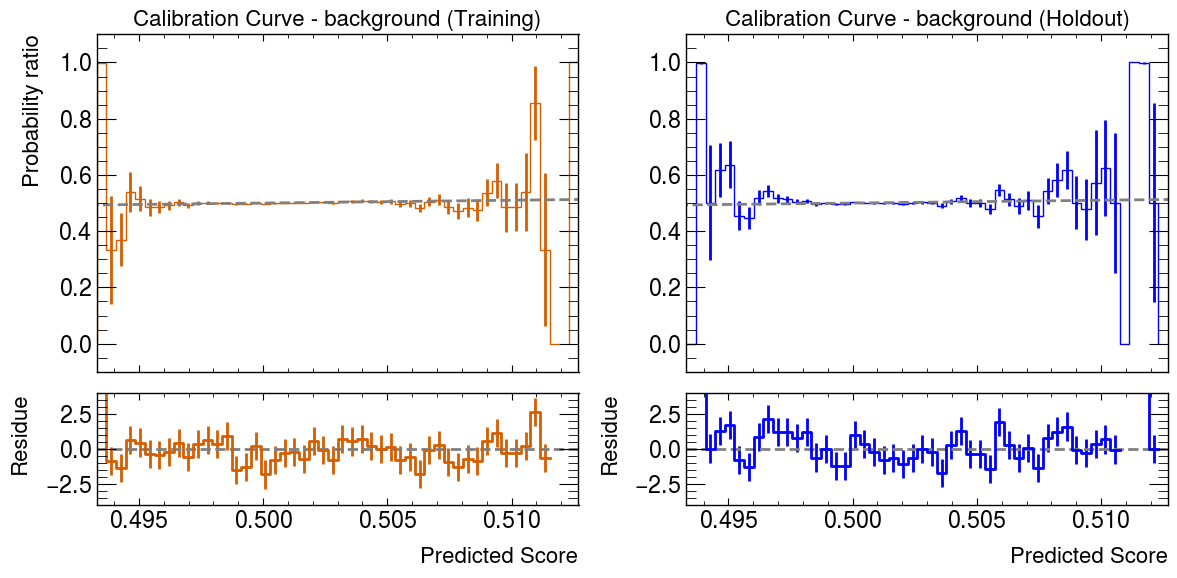

<Figure size 800x600 with 0 Axes>

In [41]:
trainer[ens_index_to_plot].make_calib_plots(observable='score', nbins=50, ensemble_index=0)

## Density ratio reweighting closure tests
  
Despite having a well-calibrated output and thus a robust probabilistic interpretation, the trained density ratios might not capture the full multi-dimensional event information $x$. 

The next diagnostic involves verifying the following equality using 1D projections of $x$:

$$R_\psi^\mathrm{bkg}(x) \times p_{ref}(x) = \frac{p_b(x)}{p_{ref}(x)} \times p_{ref}(x) \sim p_b(x)$$

We can do this one-by-one for all the observables used to model the density ratios, and also possibly the observables not used directly in the training but can still be well-estimated due to the NN learning the right physics.

/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:294: RuntimeWarning: divide by zero encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:294: RuntimeWarning: invalid value encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:295: RuntimeWarning: invalid value encountered in divide
  yerr_L = np.abs(rat_L*np.sqrt((np.sqrt(L['hist_den_err'])/L['hist_den'])**2 + (np.sqrt(L['hist_num_err'])/L['hist_num'])**2))
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:317: RuntimeWarning: divide by zero encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:317: RuntimeWarning: invalid value encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/Users/j

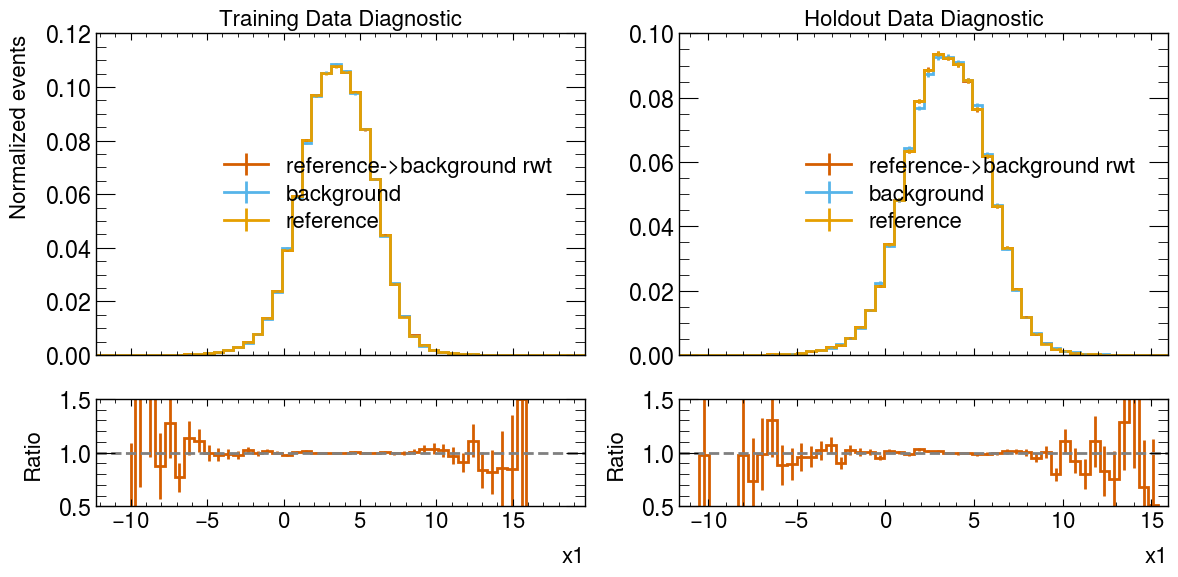

/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:294: RuntimeWarning: divide by zero encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:294: RuntimeWarning: invalid value encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:295: RuntimeWarning: invalid value encountered in divide
  yerr_L = np.abs(rat_L*np.sqrt((np.sqrt(L['hist_den_err'])/L['hist_den'])**2 + (np.sqrt(L['hist_num_err'])/L['hist_num'])**2))
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:317: RuntimeWarning: divide by zero encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:317: RuntimeWarning: invalid value encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/Users/j

<Figure size 800x600 with 0 Axes>

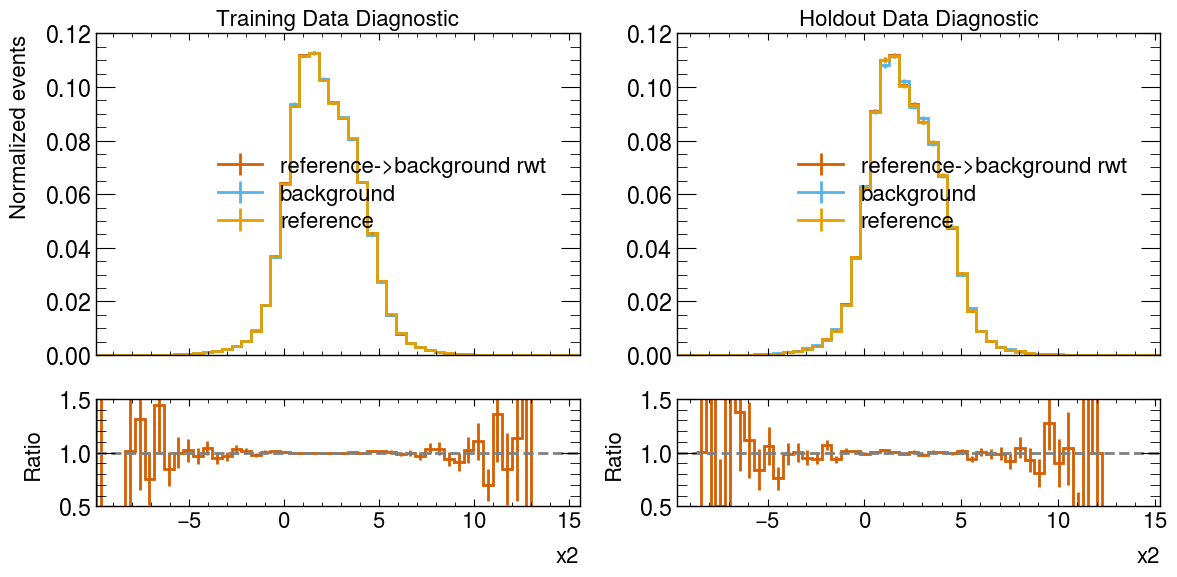

/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:294: RuntimeWarning: divide by zero encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:294: RuntimeWarning: invalid value encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:295: RuntimeWarning: invalid value encountered in divide
  yerr_L = np.abs(rat_L*np.sqrt((np.sqrt(L['hist_den_err'])/L['hist_den'])**2 + (np.sqrt(L['hist_num_err'])/L['hist_num'])**2))
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:317: RuntimeWarning: divide by zero encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:317: RuntimeWarning: invalid value encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/Users/j

<Figure size 800x600 with 0 Axes>

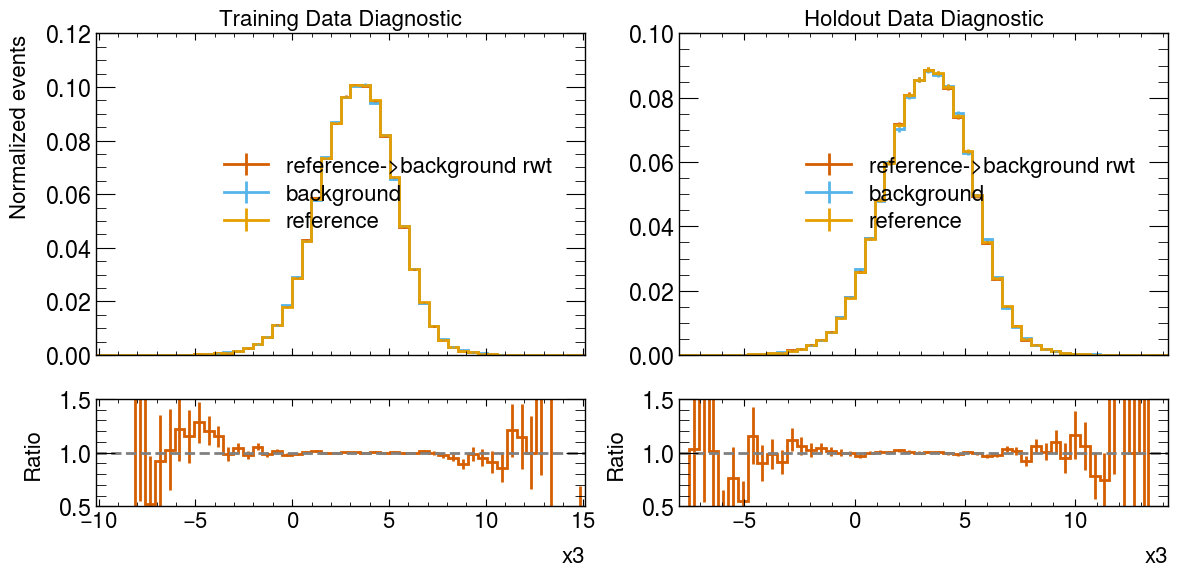

/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:294: RuntimeWarning: divide by zero encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:294: RuntimeWarning: invalid value encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:295: RuntimeWarning: invalid value encountered in divide
  yerr_L = np.abs(rat_L*np.sqrt((np.sqrt(L['hist_den_err'])/L['hist_den'])**2 + (np.sqrt(L['hist_num_err'])/L['hist_num'])**2))
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:317: RuntimeWarning: divide by zero encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:317: RuntimeWarning: invalid value encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/Users/j

<Figure size 800x600 with 0 Axes>

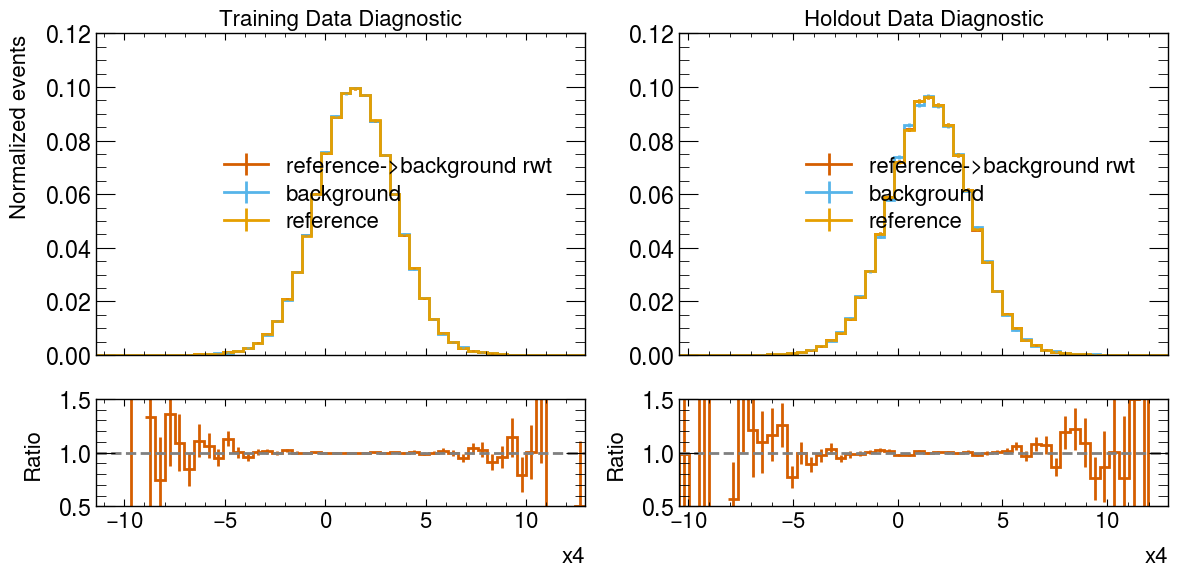

/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:294: RuntimeWarning: divide by zero encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:294: RuntimeWarning: invalid value encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:295: RuntimeWarning: invalid value encountered in divide
  yerr_L = np.abs(rat_L*np.sqrt((np.sqrt(L['hist_den_err'])/L['hist_den'])**2 + (np.sqrt(L['hist_num_err'])/L['hist_num'])**2))
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:318: RuntimeWarning: invalid value encountered in divide
  yerr_R = np.abs(rat_R*np.sqrt((np.sqrt(R['hist_den_err'])/R['hist_den'])**2 + (np.sqrt(R['hist_num_err'])/R['hist_num'])**2))


<Figure size 800x600 with 0 Axes>

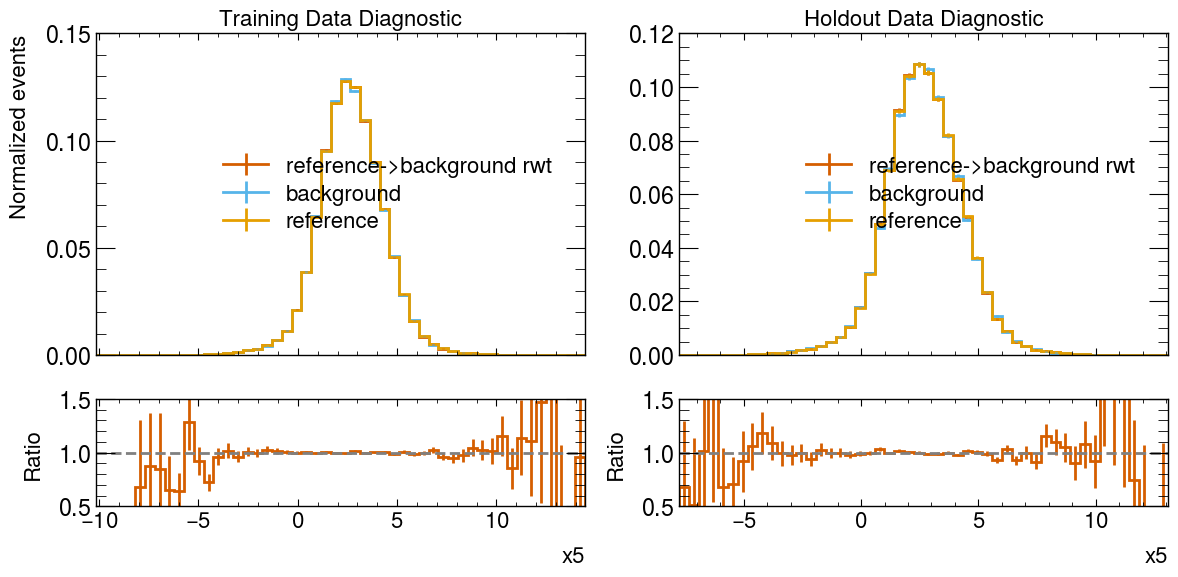

<Figure size 800x600 with 0 Axes>

In [42]:
trainer[ens_index_to_plot].make_reweighted_plots(training_features, "linear", 50)